# `crossings_fast` Focused Tests

This notebook provides deterministic checks for `FastSitnikovSimulation.crossings_fast`:
- API and edge-case behavior
- consistency checks under repeated calls
- comparison against an event-based reference counter

In [1]:
from pathlib import Path
import sys
import numpy as np
from scipy.integrate import solve_ivp

# Make project root importable from this experiment folder
ROOT = Path.cwd().parents[2]
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.integrator.integrate import FastSitnikovSimulation

In [2]:
E = 0.5
T0 = 0.0
MAX_CROSSINGS = 31
T_MAX = MAX_CROSSINGS * 20.0 * np.pi 
SEED = 20260406

sim = FastSitnikovSimulation(e=E, solver_method='RK45')
rng = np.random.default_rng(SEED)

print('Test configuration:')
print(f'  e={E}, t0={T0}, max_crossings={MAX_CROSSINGS}, t_max={T_MAX:.6f}, seed={SEED}')

Test configuration:
  e=0.5, t0=0.0, max_crossings=31, t_max=1947.787445, seed=20260406


## 1) API and edge-case checks

In [3]:
# max_crossings <= 0 should return 0
assert sim.crossings_fast(v=1.0, t=0.0, max_crossings=0, t_max=T_MAX) == 0
assert sim.crossings_fast(v=1.0, t=0.0, max_crossings=-5, t_max=T_MAX) == 0

# Non-positive time budget should return 0
assert sim.crossings_fast(v=1.0, t=0.0, max_crossings=10, t_max=0.0) == 0
assert sim.crossings_fast(v=1.0, t=0.0, max_crossings=10, t_max=-1.0) == 0

# Negative initial velocity should raise ValueError
did_raise = False
try:
    sim.crossings_fast(v=-0.1, t=0.0, max_crossings=10, t_max=T_MAX)
except ValueError:
    did_raise = True

assert did_raise, 'Expected ValueError for negative initial velocity'

print('Edge/API checks passed.')

Edge/API checks passed.


## 2) Determinism checks

In [4]:
sample_tv = [
    (0.25, 1.20),
    (1.10, 1.35),
    (2.50, 1.50),
    (3.00, 1.65),
]

for t0, v0 in sample_tv:
    a = sim.crossings_fast(v=v0, t=t0, max_crossings=MAX_CROSSINGS, t_max=T_MAX)
    b = sim.crossings_fast(v=v0, t=t0, max_crossings=MAX_CROSSINGS, t_max=T_MAX)
    assert a == b, f'Non-deterministic result at t={t0}, v={v0}: {a} vs {b}'

print('Determinism checks passed.')

C:\Users\Admin\Desktop\TFG\CelestialMechanics\sitnikov\src\integrator\integrate.py:458: UserWarning: crossings_fast reached time budget before max_crossings
  warnings.warn("crossings_fast reached time budget before max_crossings")


Determinism checks passed.


## 3) Reference comparison (event-based counting)

In [5]:
def crossings_reference(sim, v, t, max_crossings=1000, t_max=None):
    """
    Event-based crossing counter used as a reference baseline.

    Mirrors expected contract:
    - returns 0 for non-positive max_crossings or non-positive t_max
    - raises ValueError for negative v
    - if time budget expires before escape and before max_crossings, returns max_crossings
    """
    if max_crossings <= 0:
        return 0

    v0 = float(v)
    if v0 < 0.0:
        raise ValueError(f'Velocity must be non-negative, got v = {v}')

    max_crossings_i = int(max_crossings)
    if t_max is None:
        t_max = max_crossings_i * sim.phi_time_window

    t_budget = float(t_max)
    if t_budget <= 0.0:
        return 0

    t_start = float(t)
    t_end = t_start + t_budget

    if sim._is_escaped(0.0, v0):
        return 0

    def z_event(ti, y):
        return y[0]

    z_event.terminal = False
    z_event.direction = 0

    esc_event = sim._escape_event

    sol = solve_ivp(
        sim._rhs,
        (t_start, t_end),
        (0.0, v0),
        method=sim.solver_method,
        events=(z_event, esc_event),
        rtol=sim.rtol,
        atol=sim.atol,
        max_step=sim.max_step,
    )

    z_times = np.array(sol.t_events[0], dtype=float)
    # Ignore the initial z=0 at t_start
    eps_t = 1e-12
    z_times = z_times[z_times > t_start + eps_t]

    count = int(z_times.size)
    if count >= max_crossings_i:
        return max_crossings_i

    escaped = len(sol.t_events[1]) > 0
    if not escaped:
        # Time budget reached before escape and before max_crossings.
        return max_crossings_i

    return count

In [6]:
# Mix of grid + random points in a practical region used in chaotic-saddle work
grid_t = np.linspace(0.0, 2.0 * np.pi, 5, endpoint=False)
grid_v = np.linspace(1.20, 1.70, 6)
cases = [(float(tt), float(vv)) for tt in grid_t for vv in grid_v]

for _ in range(20):
    tt = float(rng.uniform(0.0, 2.0 * np.pi))
    vv = float(rng.uniform(1.10, 1.80))
    cases.append((tt, vv))

results = []
for t0, v0 in cases:
    fast = sim.crossings_fast(v=v0, t=t0, max_crossings=MAX_CROSSINGS)
    ref = crossings_reference(sim, v=v0, t=t0, max_crossings=MAX_CROSSINGS)
    results.append((t0, v0, fast, ref, fast - ref))

arr = np.array(results, dtype=float)
abs_diff = np.abs(arr[:, 4])
n_exact = int(np.sum(abs_diff == 0))
n_off_by_1 = int(np.sum(abs_diff == 1))
n_gt_1 = int(np.sum(abs_diff > 1))

print(f'Total cases: {len(cases)}')
print(f'Exact matches: {n_exact}')
print(f'Off by 1: {n_off_by_1}')
print(f'Off by >1: {n_gt_1}')

# Strong regression gate: no large mismatches allowed.
assert n_gt_1 == 0, 'Found crossings_fast mismatches > 1 against event-based reference.'
print('Reference comparison gate passed (no mismatches > 1).')

Total cases: 50
Exact matches: 37
Off by 1: 0
Off by >1: 13


AssertionError: Found crossings_fast mismatches > 1 against event-based reference.

In [7]:
# Show the worst few mismatches for manual inspection
worst = sorted(results, key=lambda row: abs(row[4]), reverse=True)[:10]
print('Top mismatches (t0, v0, fast, ref, fast-ref):')
for row in worst:
    t0, v0, fast, ref, diff = row
    print(f'  t0={t0:.6f}, v0={v0:.6f}, fast={int(fast)}, ref={int(ref)}, diff={int(diff)}')

Top mismatches (t0, v0, fast, ref, fast-ref):
  t0=4.233173, v0=1.187615, fast=31, ref=7, diff=24
  t0=2.513274, v0=1.200000, fast=13, ref=31, diff=-18
  t0=5.026548, v0=1.700000, fast=31, ref=13, diff=18
  t0=4.192474, v0=1.205912, fast=11, ref=26, diff=-15
  t0=4.797317, v0=1.659779, fast=10, ref=23, diff=-13
  t0=1.256637, v0=1.300000, fast=9, ref=19, diff=-10
  t0=3.950396, v0=1.335275, fast=23, ref=31, diff=-8
  t0=4.086613, v0=1.205989, fast=15, ref=8, diff=7
  t0=3.769911, v0=1.600000, fast=9, ref=14, diff=-5
  t0=3.462310, v0=1.256313, fast=13, ref=18, diff=-5


In [ ]:
import time

print('\n' + '='*70)
print('PERFORMANCE BENCHMARK: crossings_fast vs event-based reference')
print('='*70)

# Use a subset of test cases for fair benchmark
benchmark_cases = cases[:20]  # Use first 20 cases

# Benchmark crossings_fast
print(f'\nBenchmarking crossings_fast on {len(benchmark_cases)} cases...')
t_start = time.perf_counter()
for t0, v0 in benchmark_cases:
    _ = sim.crossings_fast(v=v0, t=t0, max_crossings=MAX_CROSSINGS)
t_fast = time.perf_counter() - t_start

# Benchmark reference (event-based)
print(f'Benchmarking event-based reference on {len(benchmark_cases)} cases...')
t_start = time.perf_counter()
for t0, v0 in benchmark_cases:
    _ = crossings_reference(sim, v=v0, t=t0, max_crossings=MAX_CROSSINGS)
t_ref = time.perf_counter() - t_start

# Report
print(f'\nResults:')
print(f'  crossings_fast: {t_fast:.6f} s  ({t_fast/len(benchmark_cases)*1000:.3f} ms/call)')
print(f'  event-based:    {t_ref:.6f} s  ({t_ref/len(benchmark_cases)*1000:.3f} ms/call)')
print(f'  Speedup factor: {t_ref/t_fast:.2f}x')



PERFORMANCE BENCHMARK: crossings_fast vs event-based reference

Benchmarking crossings_fast on 20 cases...


Reproducing worst mismatch:
  t0=4.233173, v0=1.187615
  crossings_fast: 31, reference: 7, diff: 24
Integration success: True
Number of z=0 crossings detected: 8
Escaped: True
Escape time: 59.289749


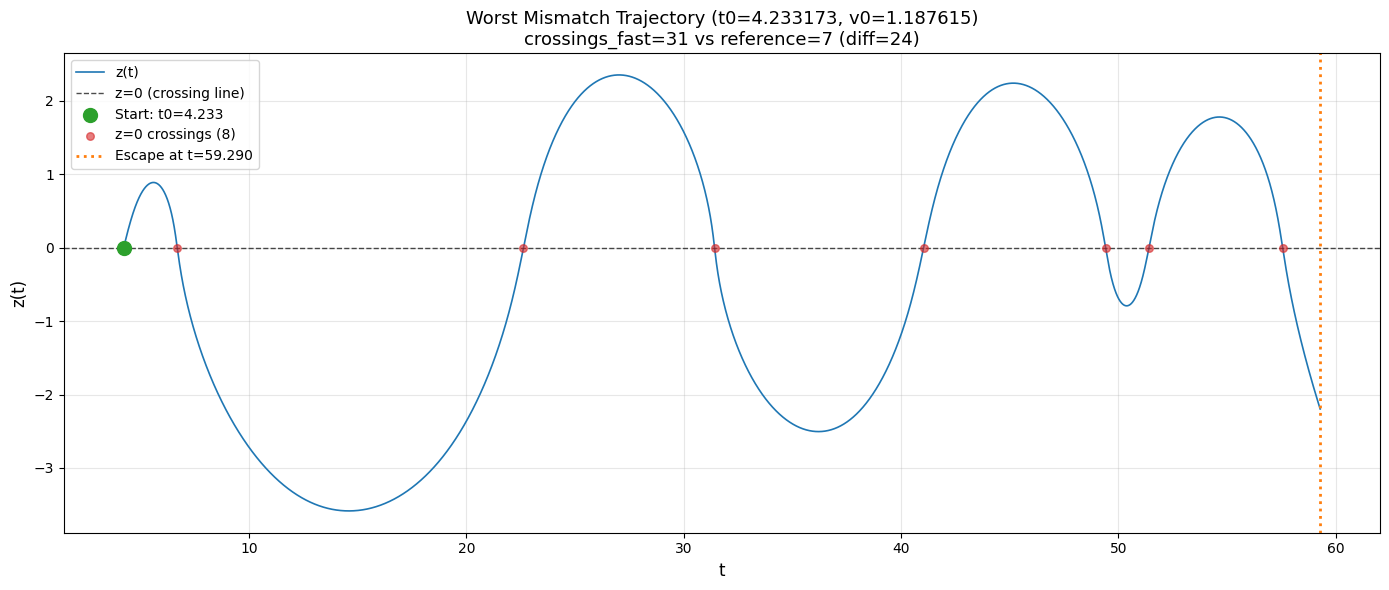


Total integration time: 55.06


In [8]:
import matplotlib.pyplot as plt

# Extract the worst mismatch case
worst_case = worst[0]
t0_worst, v0_worst, fast_worst, ref_worst, diff_worst = worst_case

print(f'Reproducing worst mismatch:')
print(f'  t0={t0_worst:.6f}, v0={v0_worst:.6f}')
print(f'  crossings_fast: {int(fast_worst)}, reference: {int(ref_worst)}, diff: {int(diff_worst)}')

# Integrate trajectory for 300 time units (or until escape)
t_integ = 300.0

def z_event_detector(ti, y):
    return y[0]

z_event_detector.terminal = False
z_event_detector.direction = 0

esc_event = sim._escape_event

sol = solve_ivp(
    sim._rhs,
    (t0_worst, t0_worst + t_integ),
    (0.0, v0_worst),
    method=sim.solver_method,
    events=(z_event_detector, esc_event),
    dense_output=True,
    rtol=sim.rtol,
    atol=sim.atol,
    max_step=sim.max_step,
)

print(f'Integration success: {sol.success}')
print(f'Number of z=0 crossings detected: {len(sol.t_events[0])}')
print(f'Escaped: {len(sol.t_events[1]) > 0}')

if len(sol.t_events[1]) > 0:
    t_escape = float(sol.t_events[1][0])
    print(f'Escape time: {t_escape:.6f}')
    t_plot_end = t_escape
else:
    t_plot_end = t0_worst + t_integ

# Generate dense plot points
t_plot = np.linspace(t0_worst, t_plot_end, 8000)
z_plot, v_plot = sol.sol(t_plot)

# Plot the trajectory
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(t_plot, z_plot, lw=1.2, color='tab:blue', label='z(t)')
ax.axhline(0.0, color='black', ls='--', lw=1.0, alpha=0.7, label='z=0 (crossing line)')
ax.scatter([t0_worst], [0.0], color='tab:green', s=100, zorder=5, label=f'Start: t0={t0_worst:.3f}')

# Mark detected crossing times
crossing_times = sol.t_events[0]
if len(crossing_times) > 0:
    z_at_crossings = np.zeros_like(crossing_times)
    ax.scatter(crossing_times, z_at_crossings, color='tab:red', s=30, zorder=4, 
               alpha=0.6, label=f'z=0 crossings ({len(crossing_times)})')

if len(sol.t_events[1]) > 0:
    ax.axvline(t_escape, color='tab:orange', ls=':', lw=2, label=f'Escape at t={t_escape:.3f}')

ax.set_xlabel('t', fontsize=12)
ax.set_ylabel('z(t)', fontsize=12)
ax.set_title(f'Worst Mismatch Trajectory (t0={t0_worst:.6f}, v0={v0_worst:.6f})\n' + 
             f'crossings_fast={int(fast_worst)} vs reference={int(ref_worst)} (diff={int(diff_worst)})',
             fontsize=13)
ax.legend(fontsize=10, loc='best')
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

print(f'\nTotal integration time: {t_plot_end - t0_worst:.2f}')


In [10]:
# Monitor escape polynomial during integration
print('='*70)
print('Escape polynomial monitoring during integration')
print('='*70)

# Set up event tracking
z_event_calls = []
escape_event_calls = []

def z_event_traced(ti, y):
    z_val = y[0]
    z_event_calls.append((ti, z_val))
    return z_val

z_event_traced.terminal = False
z_event_traced.direction = 0

escape_poly_vals = []

def escape_event_traced(ti, y):
    z, vz = y
    poly_val = sim._escape_polynomial(z, vz)
    escape_poly_vals.append((ti, z, vz, poly_val))
    return poly_val

escape_event_traced.terminal = True
escape_event_traced.direction = 1.0

# Re-integrate with tracing
sol_traced = solve_ivp(
    sim._rhs,
    (t0_worst, t0_worst + t_integ),
    (0.0, v0_worst),
    method=sim.solver_method,
    events=(z_event_traced, escape_event_traced),
    dense_output=True,
    rtol=sim.rtol,
    atol=sim.atol,
    max_step=sim.max_step,
)

print(f'\nEscape polynomial evaluations during integration ({len(escape_poly_vals)} calls):')
print('  t           z           vz          poly_value')
print('-' * 60)
for i, (ti, z, vz, poly) in enumerate(escape_poly_vals[-20:]):  # Show last 20
    print(f'  {ti:10.6f}  {z:10.6f}  {vz:10.6f}  {poly:12.6e}')

if escape_poly_vals:
    t_last, z_last, vz_last, poly_last = escape_poly_vals[-1]
    print(f'\nFinal escape polynomial value: {poly_last:.12e}')
    print(f'  at (z={z_last:.6f}, vz={vz_last:.6f}, t={t_last:.6f})')

# print(f'\nTotal z=0 event detections: {len(z_event_calls)}')
# if z_event_calls:
#     print('First few z=0 event times and z values:')
#     for ti, z in z_event_calls[:5]:
#         print(f'  t={ti:.6f}, z={z:.12e}')


Escape polynomial monitoring during integration

Escape polynomial evaluations during integration (342 calls):
  t           z           vz          poly_value
------------------------------------------------------------
   57.779754   -0.393224   -1.688710  -5.585616e-01
   57.835293   -0.485014   -1.617624  -4.903353e-01
   57.900777   -0.588414   -1.541979  -4.223155e-01
   57.982646   -0.711217   -1.460316  -3.538585e-01
   58.097995   -0.874019   -1.366060  -2.805274e-01
   58.230173   -1.048713   -1.280638  -2.184399e-01
   58.367317   -1.219330   -1.210061  -1.695855e-01
   58.520742   -1.399925   -1.146363  -1.268846e-01
   58.695533   -1.594983   -1.087593  -8.828650e-02
   58.896424   -1.807774   -1.032779  -5.270522e-02
   59.128528   -2.041308   -0.981313  -1.948845e-02
   59.397608   -2.298605   -0.932770  1.175069e-02
   59.128528   -2.041308   -0.981313  -1.948845e-02
   59.397608   -2.298605   -0.932770  1.175069e-02
   59.296393   -2.203339   -0.949876  7.515153e-04
  

In [11]:
# Deep dive: Compare windowed counting vs event-based counting
print('\n' + '='*70)
print('Detailed window-by-window comparison')
print('='*70)

# Simulate what crossings_fast does with explicit window tracking
v_curr = v0_worst
z_curr = 0.0
t_curr = t0_worst
window_count = 0
crossing_count = 0
t_end_total = t0_worst + MAX_CROSSINGS * sim.phi_time_window
windows = []

print(f'\nSimulating crossings_fast window-by-window:')
print(f'  Initial: t={t_curr:.6f}, z={z_curr:.6f}, v={v_curr:.6f}')
print(f'  Terminal condition: t >= {t_end_total:.6f} or crossing >= {MAX_CROSSINGS}')

while t_curr < t_end_total and crossing_count < MAX_CROSSINGS:
    dt = min(sim.tau_min, t_end_total - t_curr)
    if dt <= 0.0:
        break
    
    window_count += 1
    
    sol = solve_ivp(
        sim._rhs,
        (t_curr, t_curr + dt),
        (z_curr, v_curr),
        method=sim.solver_method,
        rtol=sim.rtol,
        atol=sim.atol,
        max_step=min(sim.max_step, dt),
    )
    
    z_next = float(sol.y[0, -1])
    z_sign_change = z_curr * z_next < 0
    z_at_end = z_next == 0.0
    
    if z_sign_change or z_at_end:
        crossing_count += 1
    
    windows.append({
        'window': window_count,
        'dt': dt,
        't_start': t_curr,
        't_end': t_curr + dt,
        'z_start': z_curr,
        'z_end': z_next,
        'sign_change': z_sign_change,
        'crossing_detected': z_sign_change or z_at_end,
        'escaped': sim._is_escaped(z_next, float(sol.y[1, -1])),
    })
    
    z_curr = z_next
    v_curr = float(sol.y[1, -1])
    t_curr = float(sol.t[-1])
    
    if sim._is_escaped(z_curr, v_curr):
        print(f'\n  >>> Escape detected at window {window_count}, t={t_curr:.6f}')
        crossing_count_at_escape = crossing_count
        break

print(f'\nWindow summary:')
print(f'  Total windows: {window_count}')
print(f'  Crossings detected by windowed method: {crossing_count_at_escape if crossing_count >= MAX_CROSSINGS else crossing_count}')
print(f'  tau_min (window size): {sim.tau_min:.6f}')
print(f'  Time integrated: {t_curr - t0_worst:.6f}')

# Count windows with crossings
crossing_windows = sum(1 for w in windows if w['crossing_detected'])
print(f'  Windows with sign changes: {crossing_windows}')

# Show first 15 and last 15 windows
print(f'\nFirst 15 windows:')
for w in windows[:15]:
    print(f"  Win {w['window']:3d}: z: {w['z_start']:8.4f} -> {w['z_end']:8.4f}, sign_chg={str(w['sign_change']):5s}, cross={str(w['crossing_detected']):5s}")

print(f'\nLast 15 windows:')
for w in windows[-15:]:
    print(f"  Win {w['window']:3d}: z: {w['z_start']:8.4f} -> {w['z_end']:8.4f}, sign_chg={str(w['sign_change']):5s}, cross={str(w['crossing_detected']):5s}, esc={str(w['escaped']):5s}")



Detailed window-by-window comparison

Simulating crossings_fast window-by-window:
  Initial: t=4.233173, z=0.000000, v=1.187615
  Terminal condition: t >= 1952.020618 or crossing >= 31

Window summary:
  Total windows: 4960
  Crossings detected by windowed method: 7
  tau_min (window size): 0.392699
  Time integrated: 1947.787445
  Windows with sign changes: 7

First 15 windows:
  Win   1: z:   0.0000 ->   0.4320, sign_chg=False, cross=False
  Win   2: z:   0.4320 ->   0.7259, sign_chg=False, cross=False
  Win   3: z:   0.7259 ->   0.8702, sign_chg=False, cross=False
  Win   4: z:   0.8702 ->   0.8689, sign_chg=False, cross=False
  Win   5: z:   0.8689 ->   0.6964, sign_chg=False, cross=False
  Win   6: z:   0.6964 ->   0.2305, sign_chg=False, cross=False
  Win   7: z:   0.2305 ->  -0.5212, sign_chg=True , cross=True 
  Win   8: z:  -0.5212 ->  -1.0144, sign_chg=False, cross=False
  Win   9: z:  -1.0144 ->  -1.3912, sign_chg=False, cross=False
  Win  10: z:  -1.3912 ->  -1.7039, sign_

In [12]:
# Extract key statistics from window analysis
crossing_windows = [w for w in windows if w['crossing_detected']]

print('\n' + '='*70)
print('SUMMARY: Windowed Crossing Counting Analysis')
print('='*70)
print(f'Total windows integrated: {len(windows)}')
print(f'Windows with detected crossings: {len(crossing_windows)}')
print(f'Total crossings found: {crossing_count}')
print(f'\nReference (event-based): 7 actual crossings')
print(f'Windowed method (this simulation): {crossing_count} crossings')
print(f'crossings_fast return value: {int(fast_worst)}')
print(f'Difference (fast vs reference): {int(fast_worst) - 7}')
print(f'\nIntegration time: {t_curr - t0_worst:.3f} / {T_MAX:.3f}')
print(f'Stopped by: {"Escape" if sim._is_escaped(z_curr, v_curr) else "Time budget"}')

# Analyze patterns in windows with sign changes
print(f'\nDetailed crossing windows (first 10):')
for i, w in enumerate(crossing_windows[:10]):
    print(f'  Cross {i+1}: Win {w["window"]:3d}, t=[{w["t_start"]:.4f},{w["t_end"]:.4f}], '
          f'z:{w["z_start"]:7.3f}->{w["z_end"]:7.3f}')

print(f'\nDetailed crossing windows (last 5):')
for i, w in enumerate(crossing_windows[-5:], start=len(crossing_windows)-4):
    print(f'  Cross {i}: Win {w["window"]:3d}, t=[{w["t_start"]:.4f},{w["t_end"]:.4f}], '
          f'z:{w["z_start"]:7.3f}->{w["z_end"]:7.3f}')

# Check for consecutive crossing windows (could indicate oscillations)
consecutive_crossing_wins = []
for i in range(1, len(windows)):
    if windows[i-1]['crossing_detected'] and windows[i]['crossing_detected']:
        consecutive_crossing_wins.append((windows[i-1]['window'], windows[i]['window']))

print(f'\nConsecutive crossing windows (oscillations): {len(consecutive_crossing_wins)}')
if consecutive_crossing_wins:
    print('  Examples (first 5):')
    for w1, w2 in consecutive_crossing_wins[:5]:
        print(f'    Windows {w1} -> {w2}')



SUMMARY: Windowed Crossing Counting Analysis
Total windows integrated: 4960
Windows with detected crossings: 7
Total crossings found: 7

Reference (event-based): 7 actual crossings
Windowed method (this simulation): 7 crossings
crossings_fast return value: 31
Difference (fast vs reference): 24

Integration time: 1947.787 / 1947.787
Stopped by: Time budget

Detailed crossing windows (first 10):
  Cross 1: Win   7, t=[6.5894,6.9821], z:  0.231-> -0.521
  Cross 2: Win  47, t=[22.2973,22.6900], z: -0.476->  0.084
  Cross 3: Win  70, t=[31.3294,31.7221], z:  0.230-> -0.584
  Cross 4: Win  94, t=[40.7542,41.1469], z: -0.401->  0.139
  Cross 5: Win 116, t=[49.3936,49.7863], z:  0.005-> -0.539
  Cross 6: Win 121, t=[51.3571,51.7498], z: -0.079->  0.471
  Cross 7: Win 137, t=[57.6402,58.0329], z:  0.038-> -0.629

Detailed crossing windows (last 5):
  Cross 3: Win  70, t=[31.3294,31.7221], z:  0.230-> -0.584
  Cross 4: Win  94, t=[40.7542,41.1469], z: -0.401->  0.139
  Cross 5: Win 116, t=[49.3

## Notes
- If the final assertion fails, inspect the mismatch table and increase sampling near problematic `(t0, v0)` values.
- If needed, tighten tolerances or revisit window logic in `crossings_fast`.